# Module M8: Skin Cancer Detection & Dermatological Lesion Classification (HAM10000)
### MedSynapse Clinical Decision-Support Framework

This notebook trains a deep transfer learning model on the **HAM10000 ("Human Against Machine with 10000 training images")** dataset ([kmader/skin-cancer-mnist-ham10000](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)).
It classifies dermatoscopic images into **7 diagnostic lesion categories**:
1. **Actinic keratoses (`akiec`)** — Precancerous squamous lesions
2. **Basal cell carcinoma (`bcc`)** — Common epithelial skin cancer
3. **Benign keratosis-like lesions (`bkl`)** — Solar lentigines / seborrheic keratoses
4. **Dermatofibroma (`df`)** — Benign dermal nodules
5. **Melanoma (`mel`)** — Invasive malignant melanocytic cancer
6. **Melanocytic nevi (`nv`)** — Common benign moles
7. **Vascular lesions (`vasc`)** — Angiomas and pyogenic granulomas


In [8]:
import os
import glob
from pathlib import Path
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {len(gpus)} ({[g.name for g in gpus]})")


TensorFlow Version: 2.20.0
GPUs available: 2 (['/physical_device:GPU:0', '/physical_device:GPU:1'])


In [9]:
# ====================================================================
# 🌐 DATASET AUTO-RESOLVER & HAM10000 CONNECTOR
# ====================================================================
candidate_dirs = [
    '/kaggle/input/skin-cancer-mnist-ham10000',
    '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000',
    '../input/skin-cancer-mnist-ham10000',
    '../datasets/skin_cancer_ham10000',
    './datasets/skin_cancer_ham10000',
    '/kaggle/input'
]

dataset_dir = None
meta_path = None

for d in candidate_dirs:
    if os.path.exists(d):
        for root, _, files in os.walk(d):
            for f in files:
                if f.lower() == 'ham10000_metadata.csv':
                    meta_path = os.path.join(root, f)
                    dataset_dir = os.path.dirname(meta_path)
                    break
            if meta_path:
                break
    if meta_path:
        print(f"✅ Found HAM10000 metadata at: {meta_path}")
        break

if not meta_path:
    print("⚡ Dataset not detected locally. Downloading via KaggleHub...")
    try:
        import kagglehub
        dl_path = kagglehub.dataset_download('kmader/skin-cancer-mnist-ham10000')
        print(f"✅ Downloaded to: {dl_path}")
        for root, _, files in os.walk(dl_path):
            if 'HAM10000_metadata.csv' in files or 'ham10000_metadata.csv' in [x.lower() for x in files]:
                meta_path = os.path.join(root, 'HAM10000_metadata.csv')
                dataset_dir = dl_path
                break
    except Exception as e:
        print(f"⚠️ KaggleHub error: {e}")

if not meta_path or not os.path.exists(meta_path):
    raise FileNotFoundError(
        "HAM10000 dataset not found! Please attach 'kmader/skin-cancer-mnist-ham10000' in Kaggle."
    )

# 2. Map all image files to their full paths
image_path_dict = {}
search_roots = [dataset_dir, os.path.dirname(meta_path), '/kaggle/input']
for s_dir in set(search_roots):
    if s_dir and os.path.exists(s_dir):
        for root, _, files in os.walk(s_dir):
            for f in files:
                if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_id = os.path.splitext(f)[0]
                    if img_id not in image_path_dict:
                        image_path_dict[img_id] = os.path.join(root, f)

print(f"📂 Total mapped images found: {len(image_path_dict):,}")

# 3. Load Metadata & filter existing images
df = pd.read_csv(meta_path)
df['path'] = df['image_id'].map(image_path_dict.get)
df = df.dropna(subset=['path']).reset_index(drop=True)

# 4. Clinical Class Dictionary
lesion_type_dict = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}
df['cell_type'] = df['dx'].map(lesion_type_dict.get)

# Categorical mapping
unique_classes = sorted(df['dx'].unique())
dx2label = {dx: i for i, dx in enumerate(unique_classes)}
label2dx = {i: dx for dx, i in dx2label.items()}
label2name = {i: lesion_type_dict[dx] for i, dx in enumerate(unique_classes)}

df['label'] = df['dx'].map(dx2label)

print(f"✅ Verified Dataset Rows: {len(df):,}")
print(f"Classes ({len(unique_classes)}): {label2name}")
df[['image_id', 'dx', 'cell_type', 'label', 'age', 'sex', 'localization']].head()


⚡ Dataset not detected locally. Downloading via KaggleHub...
✅ Downloaded to: /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000
📂 Total mapped images found: 11,815
✅ Verified Dataset Rows: 10,015
Classes (7): {0: 'Actinic keratoses', 1: 'Basal cell carcinoma', 2: 'Benign keratosis', 3: 'Dermatofibroma', 4: 'Melanoma', 5: 'Melanocytic nevi', 6: 'Vascular lesions'}


,image_id,dx,cell_type,label,age,sex,localization
0,ISIC_0027419,bkl,Benign keratosis,2,80.0,male,scalp
1,ISIC_0025030,bkl,Benign keratosis,2,80.0,male,scalp
2,ISIC_0026769,bkl,Benign keratosis,2,80.0,male,scalp
3,ISIC_0025661,bkl,Benign keratosis,2,80.0,male,scalp
4,ISIC_0031633,bkl,Benign keratosis,2,75.0,male,ear


/tmp/ipykernel_114/3461331905.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, palette='crest')


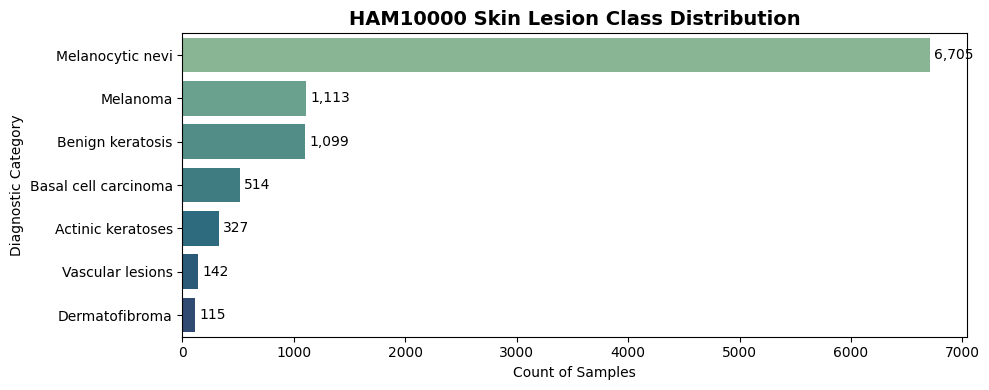

In [10]:
# Visualizing class distribution
plt.figure(figsize=(10, 4))
ax = sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, palette='crest')
plt.title('HAM10000 Skin Lesion Class Distribution', fontsize=14, weight='bold')
plt.xlabel('Count of Samples')
plt.ylabel('Diagnostic Category')
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width() + 40, p.get_y() + p.get_height()/2),
                ha='left', va='center', fontsize=10)
plt.tight_layout()
plt.show()


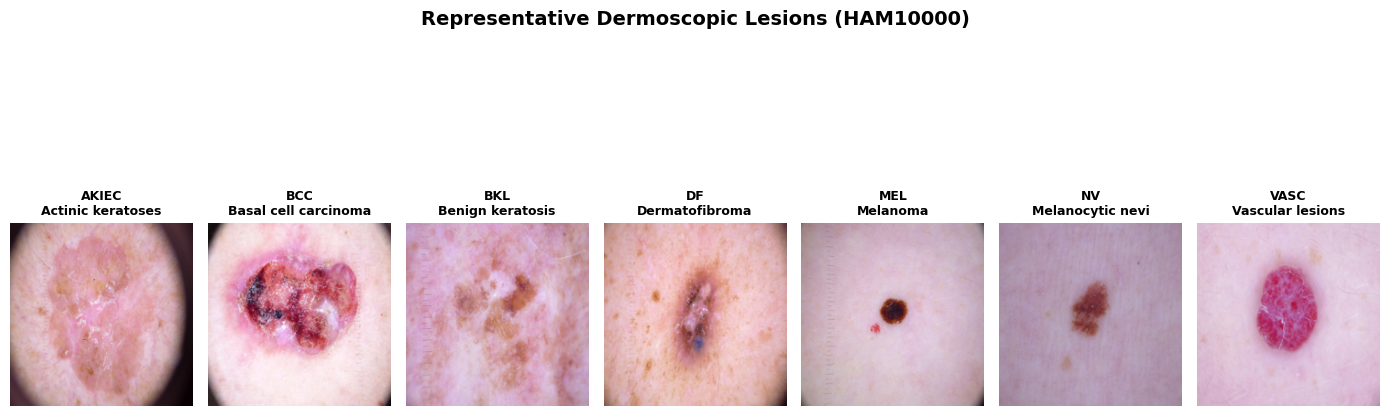

In [11]:
# Displaying sample images for each of the 7 diagnostic classes
plt.figure(figsize=(14, 6))
for idx, dx in enumerate(unique_classes):
    samples = df[df['dx'] == dx]
    if len(samples) > 0:
        sample_row = samples.iloc[0]
        img = Image.open(sample_row['path']).convert('RGB').resize((200, 200))
        plt.subplot(1, 7, idx + 1)
        plt.imshow(img)
        plt.title(f"{dx.upper()}\n{lesion_type_dict[dx]}", fontsize=9, weight='bold')
        plt.axis('off')

plt.suptitle("Representative Dermoscopic Lesions (HAM10000)", fontsize=14, weight='bold')
plt.tight_layout()
plt.show()


In [12]:
# Stratified Split: 80% Train, 10% Validation, 10% Test
df_train_val, df_test = train_test_split(df, test_size=0.10, random_state=42, stratify=df['label'])
df_train, df_val = train_test_split(df_train_val, test_size=0.1111, random_state=42, stratify=df_train_val['label'])

print(f"Train set:      {len(df_train):,} samples")
print(f"Validation set: {len(df_val):,} samples")
print(f"Test set:       {len(df_test):,} samples")

# Compute class weights to address lesion frequency imbalance
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(df_train['label']),
    y=df_train['label']
)
class_weight_dict = {i: weight for i, weight in enumerate(class_weights_arr)}
print("\nComputed Balanced Class Weights:")
for i, w in class_weight_dict.items():
    print(f"  Class {i} ({label2dx[i]} - {label2name[i]}): {w:.2f}")


Train set:      8,011 samples
Validation set: 1,002 samples
Test set:       1,002 samples

Computed Balanced Class Weights:
  Class 0 (akiec - Actinic keratoses): 4.38
  Class 1 (bcc - Basal cell carcinoma): 2.78
  Class 2 (bkl - Benign keratosis): 1.30
  Class 3 (df - Dermatofibroma): 12.44
  Class 4 (mel - Melanoma): 1.28
  Class 5 (nv - Melanocytic nevi): 0.21
  Class 6 (vasc - Vascular lesions): 10.04


In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=unique_classes,
    shuffle=True
)

val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=unique_classes,
    shuffle=False
)

test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='path',
    y_col='dx',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=unique_classes,
    shuffle=False
)


Found 8011 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.
Found 1002 validated image filenames belonging to 7 classes.


In [14]:
# Building ResNet50 Transfer Learning Architecture
base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)

# Fine-tune the top layers
for layer in base_model.layers[:-20]:
    layer.trainable = False
for layer in base_model.layers[-20:]:
    layer.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(len(unique_classes), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

model.summary()


I0000 00:00:1791464944.788715     114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1791464944.792885     114 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,154,247 (92.14 MB)

 Trainable params: 9,493,767 (36.22 MB)

 Non-trainable params: 14,660,480 (55.93 MB)

In [ ]:
EPOCHS = 15

callbacks = [
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1),
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_skin_cancer_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print("🚀 Starting Model Training on HAM10000...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


🚀 Starting Model Training on HAM10000...
Epoch 1/15


In [ ]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', lw=2)
plt.plot(history.history['val_accuracy'], label='Val Accuracy', lw=2)
plt.title('Training & Validation Accuracy', weight='bold')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', lw=2)
plt.plot(history.history['val_loss'], label='Val Loss', lw=2)
plt.title('Training & Validation Loss', weight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Evaluating on the 10% test set
test_results = model.evaluate(test_generator, verbose=1)
print(f"\n🎯 Test Accuracy:  {test_results[1] * 100:.2f}%")
print(f"🎯 Test Precision: {test_results[2]:.4f}")
print(f"🎯 Test Recall:    {test_results[3]:.4f}")

# Generating predictions and confusion matrix
test_generator.reset()
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = test_generator.classes

target_names = [label2name[i] for i in range(len(unique_classes))]
print("\n" + "="*60)
print("CLINICAL CLASSIFICATION REPORT (HAM10000 7-Class):")
print("="*60)
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[label2dx[i].upper() for i in range(len(unique_classes))],
            yticklabels=[label2dx[i].upper() for i in range(len(unique_classes))])
plt.title('Confusion Matrix - HAM10000 7-Class Test Set', weight='bold')
plt.xlabel('Predicted Pathology')
plt.ylabel('Ground Truth')
plt.tight_layout()
plt.show()


In [ ]:
# ====================================================================
# 💾 SAVE & DOWNLOAD TRAINED ARTIFACTS ON KAGGLE (HAM10000 Skin Cancer)
# ====================================================================
import os
import json
import zipfile
import shutil
from IPython.display import FileLink, display

# 1. Output setup
os.makedirs('../models', exist_ok=True)
saved_files = []

# 2. Save Trained Models (both Keras native and H5 formats)
keras_path = 'skin_cancer_model.keras'
h5_path = 'skin_cancer_model.h5'
model.save(keras_path)
model.save(h5_path)
saved_files.extend([keras_path, h5_path])
print(f"✓ Saved Model: {keras_path} and {h5_path}")

# 3. Save Class Labels & Index Mappings
classes_json = 'classes.json'
with open(classes_json, 'w') as f:
    json.dump({
        'dx2label': dx2label,
        'label2dx': label2dx,
        'label2name': label2name
    }, f, indent=2)
saved_files.append(classes_json)
print(f"✓ Saved Class Mapping: {classes_json}")

# 4. Save Performance Metrics & History
metrics_json = 'metrics.json'
with open(metrics_json, 'w') as f:
    json.dump({
        'dataset': 'HAM10000 (kmader/skin-cancer-mnist-ham10000)',
        'architecture': 'ResNet50 Transfer Learning',
        'classes': label2name,
        'test_accuracy': float(test_results[1]),
        'test_precision': float(test_results[2]),
        'test_recall': float(test_results[3]),
        'input_shape': [224, 224, 3]
    }, f, indent=2)
saved_files.append(metrics_json)
print(f"✓ Saved Performance Metrics: {metrics_json}")

# 5. Copy to repo models directory if available
for f in saved_files:
    try:
        shutil.copy(f, os.path.join('../models', f))
    except Exception:
        pass

# 6. Package all artifacts into a single ZIP for 1-Click Download
zip_filename = 'skin_cancer_artifacts.zip'
with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file_name in set(saved_files):
        if os.path.exists(file_name):
            zipf.write(file_name, os.path.basename(file_name))
            print(f"📦 Added to archive: {file_name} ({os.path.getsize(file_name):,} bytes)")

try:
    shutil.copy(zip_filename, os.path.join('../models', zip_filename))
except Exception:
    pass

print('')
print('=' * 60)
print(f'✅ All artifacts successfully saved and packaged into: {zip_filename}')
print(f'📊 Archive Size: {os.path.getsize(zip_filename) / (1024*1024):.2f} MB')
print('=' * 60)
print('')
print('👉 Click the link below to download your complete model bundle:')
display(FileLink(zip_filename))

print('\nIndividual file downloads:')
for file_name in saved_files:
    if os.path.exists(file_name):
        display(FileLink(file_name))
